# Multitemporal Analysis of Urban Surface Characteristics in Harris County, Texas

© 2025 Musa Animashaun.

This learning project uses Google Earth Engine (GEE), Python, and Landsat 8/9 imagery to examine changes in vegetation, built-up surface characteristics, and land surface temperature (LST) across Harris County, Texas.

The analysis focuses on summer conditions from 2015 to 2025 using three remote-sensing variables: NDVI, NDBI, LST

The steps includes Landsat preprocessing, cloud masking, summer median composites, spectral-index calculation, change analysis, and annual time-series analysis.

> **Note:** This notebook was developed as a learning project to strengthen my skills in Google Earth Engine, Python, and multi-temporal Earth observation analysis.

## 1. Setup and Earth Engine Initialization

In [1]:
import ee
import geemap
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from scipy.stats import linregress, pearsonr
from sklearn.metrics import r2_score

In [2]:
# Initialize Earth Engine
ee.Authenticate()
ee.Initialize(project='musa-gee-project')

print("Earth Engine initialized successfully!")

Earth Engine initialized successfully!


*** Earth Engine *** Share your feedback by taking our Annual Developer Satisfaction Survey: https://google.qualtrics.com/jfe/form/SV_9oS0DRcPvElRMNw?source=python


## 2. Study Area

I used Harris County, Texas, as the study area. The county boundary is obtained from the U.S. Census Bureau TIGER dataset available through Google Earth Engine.

In [3]:
counties = ee.FeatureCollection('TIGER/2018/Counties')

harris = (
    counties
    .filter(ee.Filter.eq('NAME', 'Harris'))
    .filter(ee.Filter.eq('STATEFP', '48'))
)

print("Number of features:", harris.size().getInfo())

# Create the county outline
harris_outline = ee.Image().byte().paint(
    featureCollection=harris,
    color=1,
    width=2
)

Number of features: 1


In [4]:
# Map the study area

study_map = geemap.Map()

study_map.centerObject(harris, 9)
study_map.add_basemap('HYBRID')

study_map.addLayer(
    harris,
    {'color': 'red'},
    'Harris County Boundary'
)

study_map



Map(center=[29.857297335637313, -95.39207742105866], controls=(WidgetControl(options=['position', 'transparent…

## 3. Landsat Preprocessing

Landsat 8 and Landsat 9 Collection 2 Level 2 imagery are used for the analysis. Images are filtered to the summer months (June–August), cloud and cloud-shadow pixels are masked using the QA bands, and the appropriate scale factors are applied to the surface reflectance and surface temperature bands.

Annual summer median composites are then created for Harris County.

In [5]:
# Mask clouds and poor-quality pixels

def mask_landsat_clouds(image):
    # Pixel quality
    qa = image.select('QA_PIXEL')

    # Cloud and shadow mask
    cloud_mask = (
        qa.bitwiseAnd(1 << 1).eq(0)
        .And(qa.bitwiseAnd(1 << 2).eq(0))
        .And(qa.bitwiseAnd(1 << 3).eq(0))
        .And(qa.bitwiseAnd(1 << 4).eq(0))
    )

    # Saturation mask
    saturation_mask = image.select('QA_RADSAT').eq(0)

    # Apply masks
    return image.updateMask(cloud_mask).updateMask(saturation_mask)

In [6]:
# Apply Landsat scale factors

def apply_scale_factors(image):
    # Surface reflectance
    optical_bands = (
        image.select('SR_B.*')
        .multiply(0.0000275)
        .add(-0.2)
    )

    # Surface temperature
    thermal_band = (
        image.select('ST_B10')
        .multiply(0.00341802)
        .add(149.0)
    )

    # Update the image bands
    return (
        image
        .addBands(optical_bands, None, True)
        .addBands(thermal_band, None, True)
    )

In [7]:
# Build the annual summer composite

def create_summer_composite(year):
    # Summer period
    start_date = f'{year}-06-01'
    end_date = f'{year}-09-01'

    # Landsat 8
    l8 = (
        ee.ImageCollection('LANDSAT/LC08/C02/T1_L2')
        .filterBounds(harris)
        .filterDate(start_date, end_date)
        .filter(ee.Filter.eq('PROCESSING_LEVEL', 'L2SP'))
    )

    # Landsat 9
    l9 = (
        ee.ImageCollection('LANDSAT/LC09/C02/T1_L2')
        .filterBounds(harris)
        .filterDate(start_date, end_date)
        .filter(ee.Filter.eq('PROCESSING_LEVEL', 'L2SP')) # L2SP containts both surface-reflectance and surface-temperature
    )

    # Merge and preprocess Landsat imagery
    collection = (
        l8.merge(l9)
        .map(mask_landsat_clouds)
        .map(apply_scale_factors)
    )

    # Summer median composite
    return collection.median().clip(harris)

## 4. Spectral Indices and Land Surface Temperature

Three variables are derived from each summer composite: NDVI, NDBI, LST


In [8]:
def add_indices(image):
    # NDVI
    ndvi = image.expression(
        '(nir - red) / (nir + red)',
        {
            'nir': image.select('SR_B5'),
            'red': image.select('SR_B4')
        }
    ).rename('NDVI')

    # NDBI
    ndbi = image.expression(
        '(swir1 - nir) / (swir1 + nir)',
        {
            'swir1': image.select('SR_B6'),
            'nir': image.select('SR_B5')
        }
    ).rename('NDBI')

    # Land surface temperature
    lst = (
        image.select('ST_B10')
        .subtract(273.15)
        .rename('LST_C')
    )

    # Add derived bands
    return image.addBands([ndvi, ndbi, lst])

In [9]:
# Build the 2015 and 2025 composites
summer_2015 = create_summer_composite(2015)
summer_2025 = create_summer_composite(2025)

# Add the analysis bands
analysis_2015 = add_indices(summer_2015)
analysis_2025 = add_indices(summer_2025)

### 4.1 Spatial Patterns in 2025

The 2025 summer composite is visualized to examine the spatial distribution of vegetation greenness, built-up/non-vegetated spectral characteristics, and land surface temperature across Harris County.

In [10]:
# Map display settings
ndvi_vis = {
    'min': -0.2,
    'max': 0.8,
    'palette': ['brown', 'yellow', 'lightgreen', 'darkgreen']
}

ndbi_vis = {
    'min': -0.4,
    'max': 0.4,
    'palette': ['blue', 'white', 'orange', 'red']
}

lst_vis = {
    'min': 25,
    'max': 50,
    'palette': ['blue', 'cyan', 'yellow', 'orange', 'red']
}

# Map the 2025 surface conditions
surface_map = geemap.Map()
surface_map.centerObject(harris, 9)
surface_map.add_basemap('HYBRID')

# Add the 2025 layers
surface_map.addLayer(
    analysis_2025.select('NDVI'),
    ndvi_vis,
    'NDVI 2025',
    True
)

surface_map.addLayer(
    analysis_2025.select('NDBI'),
    ndbi_vis,
    'NDBI 2025',
    False
)

surface_map.addLayer(
    analysis_2025.select('LST_C'),
    lst_vis,
    'LST 2025',
    False
)

# Add the county outline
surface_map.addLayer(
    harris_outline,
    {'palette': ['black']},
    'Harris County Boundary'
)

surface_map

Map(center=[29.857297335637313, -95.39207742105866], controls=(WidgetControl(options=['position', 'transparent…

## 5. Comparison of Summer Conditions in 2015 and 2025

Summer composites for 2015 and 2025 are compared to examine changes in vegetation greenness, built-up surface characteristics, and land surface temperature across Harris County.

County-wide mean values are first calculated for NDVI, NDBI, and LST. Spatial change is then calculated as:

**Change = 2025 − 2015**



In [11]:
# Variables for comparison
bands = ['NDVI', 'NDBI', 'LST_C']

# County-wide mean values
stats_2015 = analysis_2015.select(bands).reduceRegion(
    reducer=ee.Reducer.mean(),
    geometry=harris.geometry(),
    scale=30,
    maxPixels=1e9
)

stats_2025 = analysis_2025.select(bands).reduceRegion(
    reducer=ee.Reducer.mean(),
    geometry=harris.geometry(),
    scale=30,
    maxPixels=1e9
)

# Organize the results
stats_2015_dict = stats_2015.getInfo()
stats_2025_dict = stats_2025.getInfo()

comparison_df = pd.DataFrame({
    '2015': stats_2015_dict,
    '2025': stats_2025_dict
})

comparison_df

# Positive and negative values show the direction of change

,2015,2025
LST_C,40.677370,41.745030
NDBI,-0.169769,-0.178302
NDVI,0.523112,0.515593


In [12]:
# Calculate change from 2015 to 2025
ndvi_change = (
    analysis_2025.select('NDVI')
    .subtract(analysis_2015.select('NDVI'))
    .rename('NDVI_change')
)

ndbi_change = (
    analysis_2025.select('NDBI')
    .subtract(analysis_2015.select('NDBI'))
    .rename('NDBI_change')
)

lst_change = (
    analysis_2025.select('LST_C')
    .subtract(analysis_2015.select('LST_C'))
    .rename('LST_change')
)

In [13]:
# Combine the change layers
change_image = (
    ndvi_change
    .addBands(ndbi_change)
    .addBands(lst_change)
)

# Mean change across Harris County
mean_change = change_image.reduceRegion(
    reducer=ee.Reducer.mean(),
    geometry=harris.geometry(),
    scale=30,
    maxPixels=1e9
)

# Organize the results
mean_change_dict = mean_change.getInfo()

change_df = pd.DataFrame(
    mean_change_dict.items(),
    columns=['Variable', 'Mean Change']
)

change_df

,Variable,Mean Change
0,LST_change,1.098848
1,NDBI_change,-0.007969
2,NDVI_change,-0.008014


In [14]:
# LST change display settings
lst_change_vis = {
    'min': -5,
    'max': 5,
    'palette': ['blue', 'cyan', 'white', 'orange', 'red']
}

# Map LST change
lst_change_map = geemap.Map()
lst_change_map.centerObject(harris, 9)
lst_change_map.add_basemap('HYBRID')

# Add the LST change layer
lst_change_map.addLayer(
    lst_change,
    lst_change_vis,
    'LST Change',
    True
)

# Add the county outline
lst_change_map.addLayer(
    harris_outline,
    {'palette': ['black']},
    'Harris County Boundary'
)

lst_change_map

Map(center=[29.857297335637313, -95.39207742105866], controls=(WidgetControl(options=['position', 'transparent…

## 6. Annual Summer Time Series (2015–2025)

To examine changes beyond a two-year comparison, annual summer composites are generated for each year from 2015 through 2025.

For each year, mean NDVI, NDBI, and land surface temperature are calculated across Harris County. This provides an 11-year time series for examining interannual variability and longer-term patterns.

In [15]:
# Analysis years
years = list(range(2015, 2026))

results = []

for year in years:
    # Build the annual composite and indices
    composite = create_summer_composite(year)
    analysis = add_indices(composite)

    # County-wide annual means
    stats = analysis.select(bands).reduceRegion(
        reducer=ee.Reducer.mean(),
        geometry=harris.geometry(),
        scale=30,
        maxPixels=1e9
    ).getInfo()

    # Store annual results
    results.append({
        'Year': year,
        'NDVI': stats['NDVI'],
        'NDBI': stats['NDBI'],
        'LST_C': stats['LST_C']
    })

    print(f"Completed {year}")

Completed 2015
Completed 2016
Completed 2017
Completed 2018
Completed 2019
Completed 2020
Completed 2021
Completed 2022
Completed 2023
Completed 2024
Completed 2025


In [16]:
# Organize the time series
df = pd.DataFrame(results)

df

,Year,NDVI,NDBI,LST_C
0,2015,0.523112,-0.169769,40.677370
1,2016,0.521552,-0.177588,41.504282
2,2017,0.542233,-0.182557,41.198880
3,2018,0.536490,-0.172386,42.274380
4,2019,0.536123,-0.186876,40.694323
5,2020,0.523107,-0.172121,43.449814
6,2021,0.537641,-0.183950,42.664027
7,2022,0.466806,-0.117414,45.764063
8,2023,0.478009,-0.130589,44.971178
9,2024,0.515378,-0.168507,42.791950


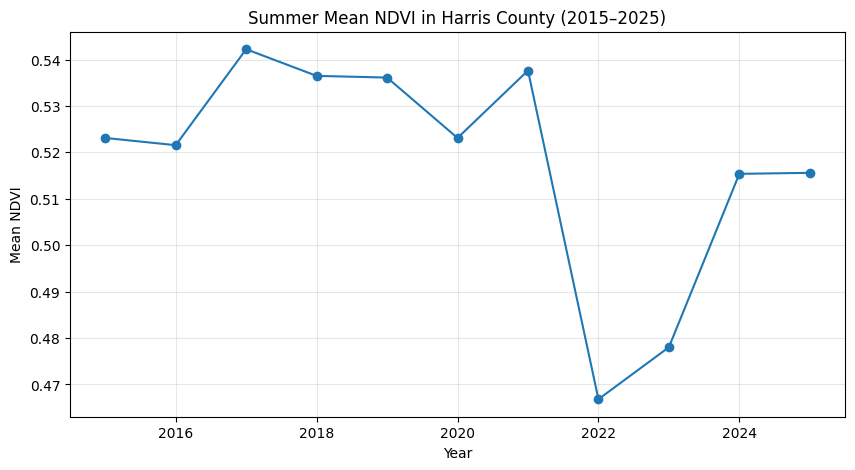

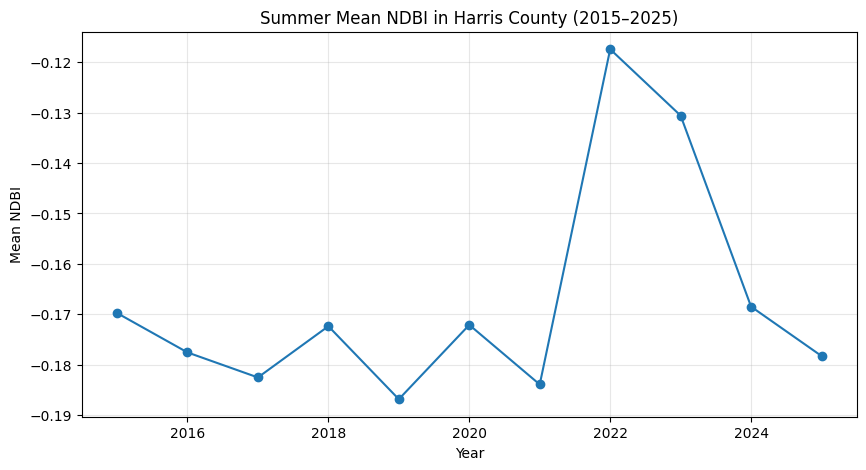

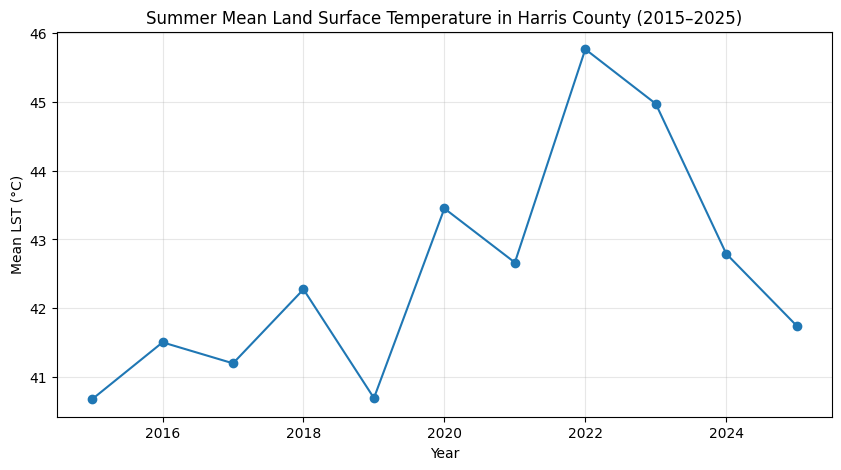

In [17]:
# NDVI time series
plt.figure(figsize=(10, 5))

plt.plot(
    df['Year'],
    df['NDVI'],
    marker='o'
)

plt.xlabel('Year')
plt.ylabel('Mean NDVI')
plt.title('Summer Mean NDVI in Harris County (2015–2025)')
plt.grid(alpha=0.3)
plt.show()


# NDBI time series
plt.figure(figsize=(10, 5))

plt.plot(
    df['Year'],
    df['NDBI'],
    marker='o'
)

plt.xlabel('Year')
plt.ylabel('Mean NDBI')
plt.title('Summer Mean NDBI in Harris County (2015–2025)')
plt.grid(alpha=0.3)
plt.show()


# LST time series
plt.figure(figsize=(10, 5))

plt.plot(
    df['Year'],
    df['LST_C'],
    marker='o'
)

plt.xlabel('Year')
plt.ylabel('Mean LST (°C)')
plt.title('Summer Mean Land Surface Temperature in Harris County (2015–2025)')
plt.grid(alpha=0.3)
plt.show()

## 7. Trend Analysis

I performed linear regression to examine the direction and strength of change in annual summer NDVI, NDBI, and land surface temperature from 2015 to 2025.

For each variable, the analysis reports:

- **Slope:** estimated annual rate and direction of change.
- **R²:** proportion of the year-to-year variation explained by the linear trend.
- **p-value:** statistical evidence for a non-zero linear trend.



In [18]:
# Fit annual trends
ndvi_trend = linregress(df['Year'], df['NDVI'])
ndbi_trend = linregress(df['Year'], df['NDBI'])
lst_trend = linregress(df['Year'], df['LST_C'])

# Report trend statistics
print(
    f"NDVI: slope = {ndvi_trend.slope:.4f}/year, "
    f"R² = {ndvi_trend.rvalue**2:.3f}, "
    f"p = {ndvi_trend.pvalue:.3f}"
)

print(
    f"NDBI: slope = {ndbi_trend.slope:.4f}/year, "
    f"R² = {ndbi_trend.rvalue**2:.3f}, "
    f"p = {ndbi_trend.pvalue:.3f}"
)

print(
    f"LST: slope = {lst_trend.slope:.3f} °C/year, "
    f"R² = {lst_trend.rvalue**2:.3f}, "
    f"p = {lst_trend.pvalue:.3f}"
)

NDVI: slope = -0.0036/year, R² = 0.236, p = 0.130
NDBI: slope = 0.0024/year, R² = 0.125, p = 0.286
LST: slope = 0.280 °C/year, R² = 0.311, p = 0.075


## 8. Relationship with Land Surface Temperature

I used Pearson correlation to examine the association between annual summer mean land surface temperature and the two spectral indices.

The analysis compares:

- NDVI and LST
- NDBI and LST



In [19]:
# Correlation with LST
ndvi_lst_r, ndvi_lst_p = pearsonr(
    df['NDVI'],
    df['LST_C']
)

ndbi_lst_r, ndbi_lst_p = pearsonr(
    df['NDBI'],
    df['LST_C']
)

# Report correlation statistics
print(
    f"NDVI vs LST: r = {ndvi_lst_r:.3f}, "
    f"p = {ndvi_lst_p:.4f}"
)

print(
    f"NDBI vs LST: r = {ndbi_lst_r:.3f}, "
    f"p = {ndbi_lst_p:.4f}"
)

NDVI vs LST: r = -0.834, p = 0.0014
NDBI vs LST: r = 0.874, p = 0.0004


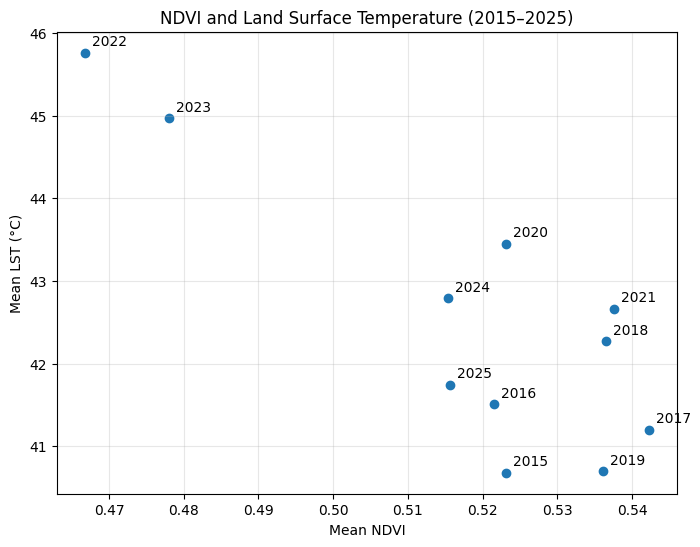

In [20]:
# NDVI and LST
plt.figure(figsize=(8, 6))

plt.scatter(
    df['NDVI'],
    df['LST_C']
)

# Label each year
for _, row in df.iterrows():
    plt.annotate(
        int(row['Year']),
        (row['NDVI'], row['LST_C']),
        xytext=(5, 5),
        textcoords='offset points'
    )

plt.xlabel('Mean NDVI')
plt.ylabel('Mean LST (°C)')
plt.title('NDVI and Land Surface Temperature (2015–2025)')
plt.grid(alpha=0.3)

plt.show()

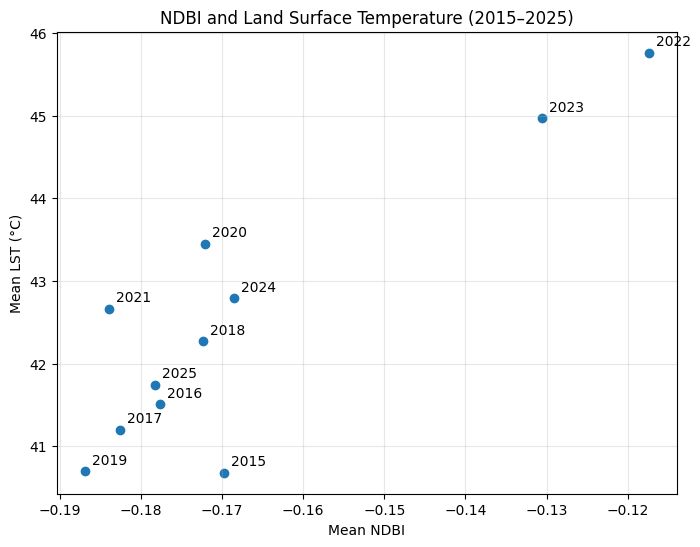

In [21]:
# NDBI and LST
plt.figure(figsize=(8, 6))

plt.scatter(
    df['NDBI'],
    df['LST_C']
)

# Label each year
for _, row in df.iterrows():
    plt.annotate(
        int(row['Year']),
        (row['NDBI'], row['LST_C']),
        xytext=(5, 5),
        textcoords='offset points'
    )

plt.xlabel('Mean NDBI')
plt.ylabel('Mean LST (°C)')
plt.title('NDBI and Land Surface Temperature (2015–2025)')
plt.grid(alpha=0.3)

plt.show()

## 9. Findings
These are my findings:

The 2015–2025 summer time series shows year-to-year changes in vegetation, built-up surface characteristics, and land surface temperature across Harris County. NDVI had a negative trend of -0.0036 per year, suggesting a general decrease in vegetation greenness over the study period. However, this trend was not statistically significant (R² = 0.236, p = 0.130). NDBI had a positive trend of +0.0024 per year, suggesting a general increase in built-up and non-vegetated surface characteristics, but this trend was also not statistically significant (R² = 0.125, p = 0.286). Mean land surface temperature showed a positive trend of about +0.28 °C per year, although the trend was not statistically significant at the 0.05 level (R² = 0.311, p = 0.075).

The results also showed strong relationships between the spectral indices and land surface temperature. NDVI had a strong negative correlation with LST (r = -0.834, p = 0.0014), meaning that years with lower vegetation greenness generally had higher surface temperatures. NDBI had a strong positive correlation with LST (r = 0.874, p = 0.0004), meaning that years with higher NDBI values generally had higher surface temperatures.



##10. Export Images

In [22]:
import os
import rasterio
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap

# Output folder
os.makedirs('figures', exist_ok=True)


def export_github_map(
    image,
    vis_params,
    filename,
    title,
    colorbar_label,
    export_scale=60
):
    # Temporary raster
    tif_filename = f"figures/{filename.replace('.png', '.tif')}"
    png_filename = f"figures/{filename}"

    # Export the raster from Earth Engine
    geemap.ee_export_image(
        image,
        filename=tif_filename,
        scale=export_scale,
        region=harris.geometry(),
        file_per_band=False
    )

    # Check the export
    if not os.path.exists(tif_filename):
        print(f"Export failed: {filename}")
        return

    # Read the exported raster
    with rasterio.open(tif_filename) as src:
        data = src.read(1)
        bounds = src.bounds
        nodata = src.nodata

    # Mask NoData
    if nodata is not None:
        data = data.astype('float32')
        data[data == nodata] = float('nan')

    # Match the Earth Engine palette
    cmap = LinearSegmentedColormap.from_list(
        'gee_palette',
        vis_params['palette']
    )

    # Create the figure
    fig, ax = plt.subplots(figsize=(9, 8))

    # Plot the raster
    im = ax.imshow(
        data,
        extent=[
            bounds.left,
            bounds.right,
            bounds.bottom,
            bounds.top
        ],
        origin='upper',
        cmap=cmap,
        vmin=vis_params['min'],
        vmax=vis_params['max']
    )

    # Title
    ax.set_title(
        title,
        fontsize=14,
        pad=15
    )

    # Coordinate labels
    ax.set_xlabel('Easting')
    ax.set_ylabel('Northing')

    # Color bar
    cbar = fig.colorbar(
        im,
        ax=ax,
        orientation='horizontal',
        pad=0.08,
        fraction=0.05
    )

    cbar.set_label(colorbar_label)

    # Finalize the figure
    ax.grid(False)

    plt.tight_layout()

    # Save the figure
    plt.savefig(
        png_filename,
        dpi=200,
        bbox_inches='tight'
    )

    plt.close()

    # Remove the temporary raster
    os.remove(tif_filename)

    print(f"Saved: {png_filename}")

In [23]:
export_github_map(
    analysis_2025.select('NDVI'),
    ndvi_vis,
    'ndvi_2025.png',
    'Summer NDVI — Harris County, Texas (2025)',
    'NDVI'
)

export_github_map(
    analysis_2025.select('NDBI'),
    ndbi_vis,
    'ndbi_2025.png',
    'Summer NDBI — Harris County, Texas (2025)',
    'NDBI'
)

export_github_map(
    analysis_2025.select('LST_C'),
    lst_vis,
    'lst_2025.png',
    'Summer Land Surface Temperature — Harris County, Texas (2025)',
    'Land Surface Temperature (°C)'
)

Generating URL ...
Please wait ...
Data downloaded to /content/figures/ndvi_2025.tif
Saved: figures/ndvi_2025.png
Generating URL ...
Please wait ...
Data downloaded to /content/figures/ndbi_2025.tif
Saved: figures/ndbi_2025.png
Generating URL ...
Please wait ...
Data downloaded to /content/figures/lst_2025.tif
Saved: figures/lst_2025.png


In [24]:
ndvi_change_vis = {
    'min': -0.3,
    'max': 0.3,
    'palette': ['brown', 'white', 'darkgreen']
}

ndbi_change_vis = {
    'min': -0.3,
    'max': 0.3,
    'palette': ['blue', 'white', 'red']
}

lst_change_vis = {
    'min': -5,
    'max': 5,
    'palette': ['blue', 'cyan', 'white', 'orange', 'red']
}

In [25]:
export_github_map(
    ndvi_change,
    ndvi_change_vis,
    'ndvi_change_2015_2025.png',
    'NDVI Change — Harris County, Texas (2015–2025)',
    'Change in NDVI'
)

export_github_map(
    ndbi_change,
    ndbi_change_vis,
    'ndbi_change_2015_2025.png',
    'NDBI Change — Harris County, Texas (2015–2025)',
    'Change in NDBI'
)

export_github_map(
    lst_change,
    lst_change_vis,
    'lst_change_2015_2025.png',
    'Land Surface Temperature Change — Harris County, Texas (2015–2025)',
    'Change in LST (°C)'
)

Generating URL ...
Please wait ...
Data downloaded to /content/figures/ndvi_change_2015_2025.tif
Saved: figures/ndvi_change_2015_2025.png
Generating URL ...
Please wait ...
Data downloaded to /content/figures/ndbi_change_2015_2025.tif
Saved: figures/ndbi_change_2015_2025.png
Generating URL ...
Please wait ...
Data downloaded to /content/figures/lst_change_2015_2025.tif
Saved: figures/lst_change_2015_2025.png
